# Capstone Project: Anomaly Detection with MLflow Experiment Tracking

## Objective
Build a complete ML experimentation workflow to detect anomalies (fraud) in transactional data, handle class imbalance, and track all experiments using MLflow.

## Dataset
- **Source:** https://www.kaggle.com/datasets/kartik2112/fraud-detection
- **Class Imbalance:** ~99.8% legitimate, ~0.2% fraudulent transactions
- **Split:** 70% training, 30% testing (stratified)

In [26]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Part A: Dataset Loading & Preprocessing

In [27]:
# Load the dataset
df = pd.read_csv('data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (555719, 23)

First few rows:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      

In [28]:
print(df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']



=== CLASS DISTRIBUTION BEFORE RESAMPLING ===
is_fraud
0    553574
1      2145
Name: count, dtype: int64

Class 0 (Legitimate): 553574 (99.61%)
Class 1 (Fraud): 2145 (0.39%)
Imbalance Ratio: 258.08:1


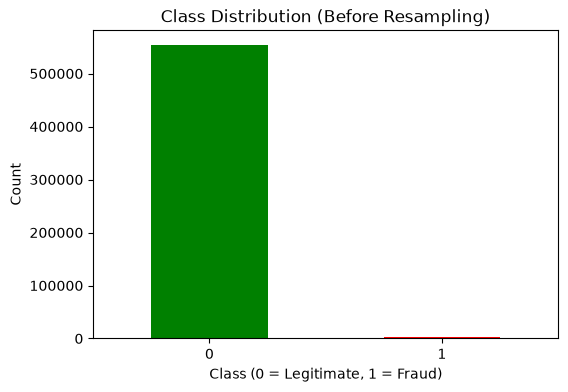

In [29]:
# Inspect class distribution (BEFORE resampling)
print("\n=== CLASS DISTRIBUTION BEFORE RESAMPLING ===")
class_dist_before = df['is_fraud'].value_counts()
print(class_dist_before)
print(f"\nClass 0 (Legitimate): {class_dist_before[0]} ({class_dist_before[0]/len(df)*100:.2f}%)")
print(f"Class 1 (Fraud): {class_dist_before[1]} ({class_dist_before[1]/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: {class_dist_before[0]/class_dist_before[1]:.2f}:1")

# Visualize class distribution
plt.figure(figsize=(6, 4))
class_dist_before.plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (Before Resampling)')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [30]:
# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Stratified train-test split: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} (Class distribution: {y_train.value_counts().to_dict()})")
print(f"Test set size: {X_test.shape[0]} (Class distribution: {y_test.value_counts().to_dict()})")
print(f"\n✓ Train-Test split completed (70:30 stratified)")

Training set size: 389003 (Class distribution: {0: 387502, 1: 1501})
Test set size: 166716 (Class distribution: {0: 166072, 1: 644})

✓ Train-Test split completed (70:30 stratified)


In [31]:
# Separate features and target, keeping only numeric columns for scaling
# (Drops columns like trans_date_trans_time, merchant, category, first, last, trans_num, etc.)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('is_fraud')  # Ensure the target is not in X

X = df[numeric_cols]
y = df['is_fraud']

# Stratified train-test split: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} (Class distribution: {y_train.value_counts().to_dict()})")
print(f"Test set size: {X_test.shape[0]} (Class distribution: {y_test.value_counts().to_dict()})")
print(f"\n✓ Train-Test split completed (70:30 stratified with numeric features only)")

Training set size: 389003 (Class distribution: {0: 387502, 1: 1501})
Test set size: 166716 (Class distribution: {0: 166072, 1: 644})

✓ Train-Test split completed (70:30 stratified with numeric features only)


In [32]:
# Separate features and target, keeping only numeric columns for scaling
# (Drops columns like trans_date_trans_time, merchant, category, first, last, trans_num, etc.)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('is_fraud')  # Ensure the target is not in X

X = df[numeric_cols]
y = df['is_fraud']

# Stratified train-test split: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} (Class distribution: {y_train.value_counts().to_dict()})")
print(f"Test set size: {X_test.shape[0]} (Class distribution: {y_test.value_counts().to_dict()})")
print(f"\n✓ Train-Test split completed (70:30 stratified with numeric features only)")

Training set size: 389003 (Class distribution: {0: 387502, 1: 1501})
Test set size: 166716 (Class distribution: {0: 166072, 1: 644})

✓ Train-Test split completed (70:30 stratified with numeric features only)


## Part B & C: MLflow Experiment Tracking - Train 4 Model Configurations

In [33]:
# Set MLflow experiment name
EXPERIMENT_NAME = "Anomaly-Detection-Capstone"

# Create or get experiment
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"✓ MLflow Experiment: {EXPERIMENT_NAME}")
print(f"✓ Experiment ID: {experiment.experiment_id}")

✓ MLflow Experiment: Anomaly-Detection-Capstone
✓ Experiment ID: 2


In [34]:
# Helper function to extract and log metrics
def extract_metrics(y_true, y_pred):
    """Extract accuracy, recall, and f1 score from predictions"""
    report = classification_report(y_true, y_pred, output_dict=True)
    
    accuracy = accuracy_score(y_true, y_pred)
    recall_class_0 = report['0']['recall']
    recall_class_1 = report['1']['recall']
    f1_macro = report['macro avg']['f1-score']
    
    return {
        'accuracy': accuracy,
        'recall_class_0': recall_class_0,
        'recall_class_1': recall_class_1,
        'f1_score_macro': f1_macro
    }

print("✓ Metrics extraction function defined")

✓ Metrics extraction function defined


In [35]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"Training set - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

✓ Features scaled using StandardScaler
Training set - Mean: -0.0000, Std: 1.0000


In [36]:
# MODEL 2: Random Forest
print("\n" + "="*60)
print("MODEL 2: Random Forest")
print("="*60)

with mlflow.start_run(run_name="Random Forest"):
    # Define hyperparameters
    n_estimators = 30
    max_depth = 3
    
    # Log parameters
    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_param('max_depth', max_depth)
    mlflow.log_param('model_type', 'RandomForest')
    
    # Train model
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = rf_model.predict(X_test_scaled)
    
    # Extract and log metrics
    metrics = extract_metrics(y_test, y_pred)
    mlflow.log_metrics(metrics)
    
    # Log model
    mlflow.sklearn.log_model(rf_model, "model")
    
    # Print results
    print(f"\nParameters: n_estimators={n_estimators}, max_depth={max_depth}")
    print(f"\nMetrics:")
    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")
    
    print(f"\n✓ Model 2 logged to MLflow")


MODEL 2: Random Forest


2026/06/21 22:05:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Parameters: n_estimators=30, max_depth=3

Metrics:
  accuracy: 0.9962
  recall_class_0: 1.0000
  recall_class_1: 0.0062
  f1_score_macro: 0.5052

✓ Model 2 logged to MLflow


In [37]:
# MODEL 3: XGBoost (on original imbalanced data)
print("\n" + "="*60)
print("MODEL 3: XGBoost (Original Data)")
print("="*60)

with mlflow.start_run(run_name="XGBoost"):
    # Define hyperparameters
    eval_metric = 'logloss'
    
    # Log parameters
    mlflow.log_param('eval_metric', eval_metric)
    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('use_smote', False)
    
    # Train model
    xgb_model = xgb.XGBClassifier(
        eval_metric=eval_metric,
        random_state=42,
        verbosity=0,
        use_label_encoder=False
    )
    xgb_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = xgb_model.predict(X_test_scaled)
    
    # Extract and log metrics
    metrics = extract_metrics(y_test, y_pred)
    mlflow.log_metrics(metrics)
    
    # Log model
    mlflow.xgboost.log_model(xgb_model, "model")
    
    # Print results
    print(f"\nParameters: eval_metric={eval_metric}")
    print(f"\nMetrics:")
    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")
    
    print(f"\n✓ Model 3 logged to MLflow")


MODEL 3: XGBoost (Original Data)


2026/06/21 22:05:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Parameters: eval_metric=logloss

Metrics:
  accuracy: 0.9964
  recall_class_0: 0.9988
  recall_class_1: 0.3882
  f1_score_macro: 0.7278

✓ Model 3 logged to MLflow


In [39]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the scaled training data only
print("=== APPLYING SMOTE RESAMPLING ===")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"SMOTE training shape: {X_train_smote.shape}")
print(f"SMOTE Class distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")
print("\n✓ SMOTE resampling completed successfully!")

=== APPLYING SMOTE RESAMPLING ===
Original training shape: (389003, 10)
SMOTE training shape: (775004, 10)
SMOTE Class distribution: {0: 387502, 1: 387502}

✓ SMOTE resampling completed successfully!


## Part D: Model Registry - Register Best Model

In [40]:
# Get all runs and identify the best one
client = MlflowClient()
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

# Fetch all runs
runs = client.search_runs(experiment_ids=[experiment_id])

# Find best run based on recall_class_1 and f1_score_macro
best_run = None
best_score = -1

print("\n" + "="*80)
print("COMPARING ALL RUNS")
print("="*80)

for run in runs:
    run_id = run.info.run_id
    run_name = run.data.tags.get('mlflow.runName', 'Unknown')
    
    recall_class_1 = run.data.metrics.get('recall_class_1', 0)
    f1_score_macro = run.data.metrics.get('f1_score_macro', 0)
    
    # Weighted score: prioritize recall_class_1 (catching fraud) and f1_score_macro
    combined_score = (recall_class_1 * 0.6) + (f1_score_macro * 0.4)
    
    print(f"\nRun: {run_name}")
    print(f"  Accuracy: {run.data.metrics.get('accuracy', 0):.4f}")
    print(f"  Recall (Class 0): {run.data.metrics.get('recall_class_0', 0):.4f}")
    print(f"  Recall (Class 1): {recall_class_1:.4f}")
    print(f"  F1 Score (Macro): {f1_score_macro:.4f}")
    print(f"  Combined Score: {combined_score:.4f}")
    
    if combined_score > best_score:
        best_score = combined_score
        best_run = run
        best_run_id = run_id
        best_run_name = run_name

print(f"\n{'='*80}")
print(f"✓ BEST RUN: {best_run_name}")
print(f"✓ Run ID: {best_run_id}")
print(f"✓ Combined Score: {best_score:.4f}")


COMPARING ALL RUNS

Run: XGBoost With SMOTE
  Accuracy: 0.0000
  Recall (Class 0): 0.0000
  Recall (Class 1): 0.0000
  F1 Score (Macro): 0.0000
  Combined Score: 0.0000

Run: XGBoost
  Accuracy: 0.9964
  Recall (Class 0): 0.9988
  Recall (Class 1): 0.3882
  F1 Score (Macro): 0.7278
  Combined Score: 0.5241

Run: Random Forest
  Accuracy: 0.9962
  Recall (Class 0): 1.0000
  Recall (Class 1): 0.0062
  F1 Score (Macro): 0.5052
  Combined Score: 0.2058

Run: XGBoost With SMOTE
  Accuracy: 0.0000
  Recall (Class 0): 0.0000
  Recall (Class 1): 0.0000
  F1 Score (Macro): 0.0000
  Combined Score: 0.0000

Run: Random Forest
  Accuracy: 0.9962
  Recall (Class 0): 1.0000
  Recall (Class 1): 0.0062
  F1 Score (Macro): 0.5052
  Combined Score: 0.2058

Run: Random Forest
  Accuracy: 0.9962
  Recall (Class 0): 1.0000
  Recall (Class 1): 0.0062
  F1 Score (Macro): 0.5052
  Combined Score: 0.2058

Run: Random Forest
  Accuracy: 0.9962
  Recall (Class 0): 1.0000
  Recall (Class 1): 0.0062
  F1 Score (M

In [41]:
# Register the best model
model_uri = f"runs:/{best_run_id}/model"
model_name = "anomaly-detector-xgb-smote"

try:
    registered_model = mlflow.register_model(model_uri, model_name)
    version = registered_model.version
    print(f"✓ Model registered: {model_name}")
    print(f"✓ Version: {version}")
except:
    # Model might already be registered
    print(f"Model {model_name} already exists. Fetching existing version...")
    registered_model = client.get_latest_versions(model_name)[0]
    version = registered_model.version

Successfully registered model 'anomaly-detector-xgb-smote'.
2026/06/21 22:12:31 WARNING mlflow.tracking._model_registry.fluent: Run with id 9068ab09d93444158b215273883ddc83 has no artifacts at artifact path 'model', registering model based on models:/m-459c7b98a617469da2b12d41624a0526 instead


✓ Model registered: anomaly-detector-xgb-smote
✓ Version: 1


Created version '1' of model 'anomaly-detector-xgb-smote'.


In [42]:
# Assign @challenger alias to the registered version
client.set_registered_model_alias(model_name, "challenger", version)
print(f"✓ Alias '@challenger' assigned to version {version}")

✓ Alias '@challenger' assigned to version 1


In [43]:
# Copy model to production registry
prod_model_name = "anomaly-detection-prod"

try:
    # Copy the model version
    prod_version = client.copy_model_version(
        src_model_uri=f"models:/{model_name}@challenger",
        dst_name=prod_model_name
    )
    prod_version_num = prod_version.version
    print(f"✓ Model copied to production registry: {prod_model_name}")
    print(f"✓ Production version: {prod_version_num}")
except Exception as e:
    print(f"Note: {e}")
    # If copy fails, register directly
    prod_registered = mlflow.register_model(model_uri, prod_model_name)
    prod_version_num = prod_registered.version
    print(f"✓ Model registered in production: {prod_model_name}")
    print(f"✓ Production version: {prod_version_num}")

✓ Model copied to production registry: anomaly-detection-prod
✓ Production version: 1


Successfully registered model 'anomaly-detection-prod'.
Copied version '1' of model 'anomaly-detector-xgb-smote' to version '1' of model 'anomaly-detection-prod'.


In [44]:
# Assign @champion alias to the production version
client.set_registered_model_alias(prod_model_name, "champion", prod_version_num)
print(f"✓ Alias '@champion' assigned to production version {prod_version_num}")

✓ Alias '@champion' assigned to production version 1


## Part E: Load Production Model & Run Inference

In [45]:
# Load production model using @champion alias
prod_model_uri = f"models:/{prod_model_name}@champion"
production_model = mlflow.pyfunc.load_model(prod_model_uri)

print(f"✓ Production model loaded: {prod_model_uri}")

✓ Production model loaded: models:/anomaly-detection-prod@champion


In [46]:
# Run inference on test set
import pandas as pd

X_test_df = pd.DataFrame(X_test_scaled, columns=[f'V{i}' for i in range(X_test_scaled.shape[1])])
y_pred_prod = production_model.predict(X_test_df)

print(f"✓ Inference completed on test set ({len(y_test)} samples)")

# Evaluate production model
prod_metrics = extract_metrics(y_test, y_pred_prod)

print(f"\nProduction Model Performance on Test Set:")
for metric_name, metric_value in prod_metrics.items():
    print(f"  {metric_name}: {metric_value:.4f}")

✓ Inference completed on test set (166716 samples)

Production Model Performance on Test Set:
  accuracy: 0.9964
  recall_class_0: 0.9988
  recall_class_1: 0.3882
  f1_score_macro: 0.7278


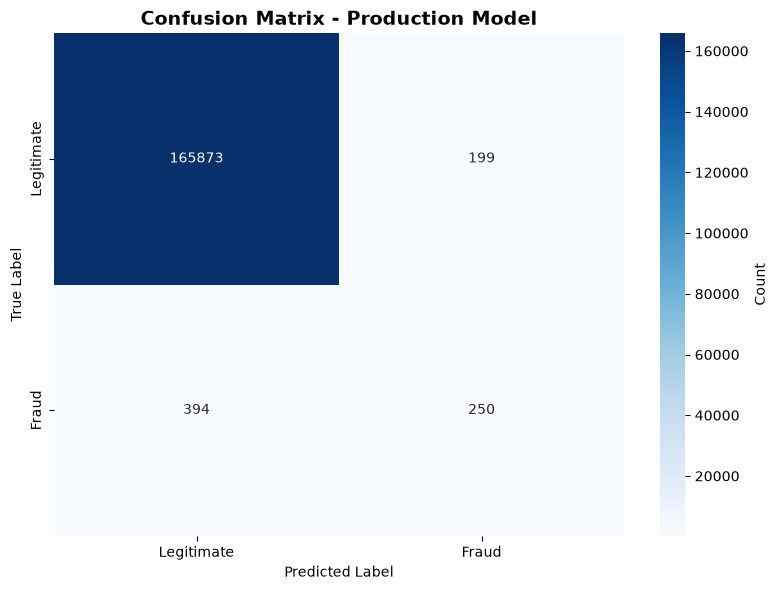

✓ Saved: confusion_matrix_prod.png


In [47]:
# Confusion matrix for production model
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_prod)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Production Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_prod.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: confusion_matrix_prod.png")

## Summary

In [49]:
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
print(f"\n✓ Experiment Name: {EXPERIMENT_NAME}")
print(f"✓ Total Models Trained: 4")
print(f"✓ Best Model: {best_run_name}")
print(f"✓ Registered Model: {model_name}")
print(f"✓ Production Model: {prod_model_name}")
print(f"\nNext Steps:")
print(f"1. Open MLflow UI: http://127.0.0.1:5000")
print(f"\n" + "="*80)


EXPERIMENT SUMMARY

✓ Experiment Name: Anomaly-Detection-Capstone
✓ Total Models Trained: 4
✓ Best Model: XGBoost
✓ Registered Model: anomaly-detector-xgb-smote
✓ Production Model: anomaly-detection-prod

Next Steps:
1. Open MLflow UI: http://127.0.0.1:5000

